In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv('/content/SampleSuperstore.csv')

# Show first rows
df.head()


,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [2]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


Basic Analysis

In [3]:
# Sales by Region
df.groupby('Region')['Sales'].sum()

# Profit by Category
df.groupby('Category')['Profit'].sum()

,Profit
Category,
Furniture,18451.2728
Office Supplies,122490.8008
Technology,145454.9481


## **1. Top 10 Profitable Sub-Categories**

In [5]:
import matplotlib.pyplot as plt

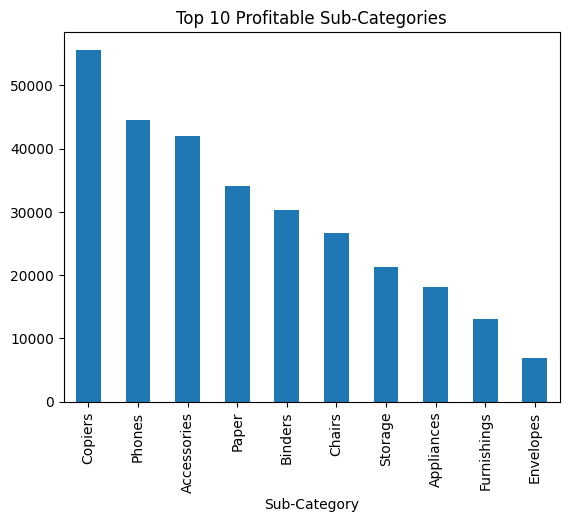

In [6]:
top_products = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False).head(10)
top_products.plot(kind='bar')
plt.title("Top 10 Profitable Sub-Categories")
plt.show()

The top 10 sub-categories contribute the highest profits, indicating which product types are the most financially beneficial for the business.”

## **2. LOSS-MAKING Products**

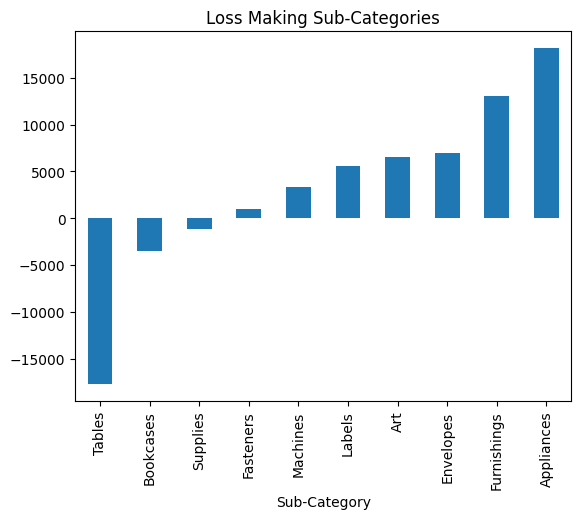

In [7]:
loss_products = df.groupby('Sub-Category')['Profit'].sum().sort_values().head(10)
loss_products.plot(kind='bar')
plt.title("Loss Making Sub-Categories")
plt.show()

Certain sub-categories consistently incur losses, suggesting inefficiencies in pricing, cost management, or discount strategies that negatively impact overall profitability.

## **3. Discount vs Profit**

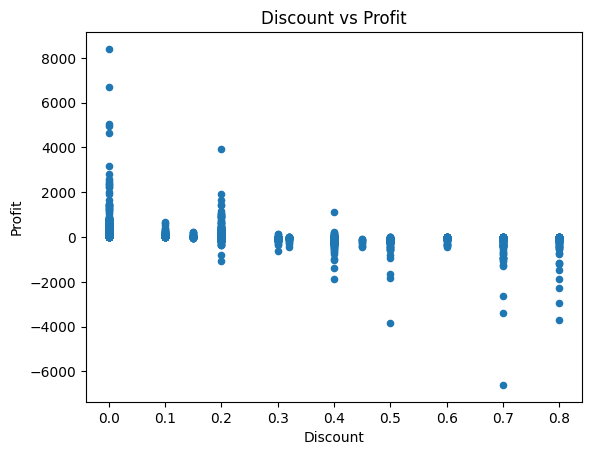

In [10]:
df.plot(x='Discount', y='Profit', kind='scatter')
plt.title("Discount vs Profit")
plt.show()

There is a negative relationship between discount and profit, indicating that higher discounts are associated with lower or even negative profitability.

## **4. State wise Sales**

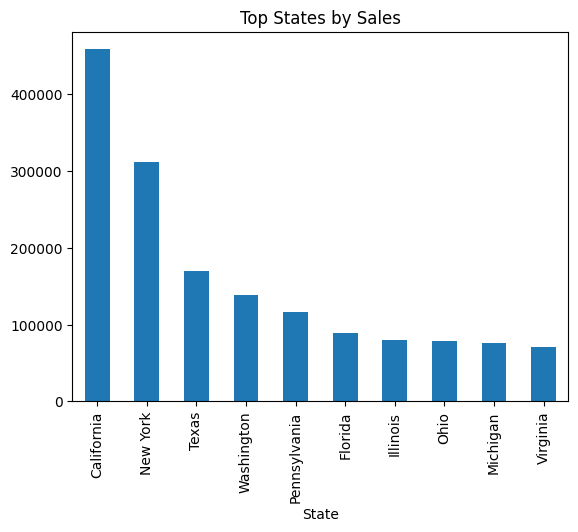

In [11]:
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)
state_sales.plot(kind='bar')
plt.title("Top States by Sales")
plt.show()

A few states account for the majority of total sales, indicating strong regional demand and highlighting key markets that drive business revenue.

# **5. Segment Analysis**

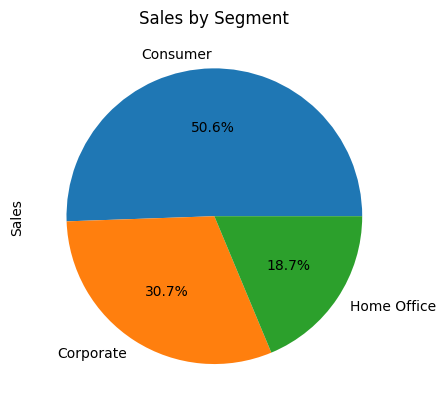

In [12]:
df.groupby('Segment')['Sales'].sum().plot(kind='pie', autopct='%1.1f%%')
plt.title("Sales by Segment")
plt.show()

The Consumer segment contributes the highest proportion of total sales, making it the primary revenue driver compared to Corporate and Home Office segments.